# Regression analysis - LR Batch Size Combined Variation

## First run - sc4422

### Parameters
wcte_regression.yaml

Overrides: 

data.dataset.transforms=['double_cover'] model.conv_pad_mode='circular' \
tasks.train.data_loaders.train.batch_size=1024 \
tasks.evaluate.data_loaders.test.batch_size=2048 \
tasks.train.data_loaders.validation.batch_size=2048 \
tasks.train.data_loaders.train.pre_transforms=[]


### Data/ Paths

Electron run: \
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/e_FC.npz' \
Muon run: \
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/e_FC.npz' \
data.dataset.geometry_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz' \
data.dataset.mpmt_positions_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/mpmt_pos_files/WCTE_mpmt_position_correct_251125.npz' \
data.dataset.h5file='/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5'

### Disclaimer

### Outputs
Run directory: /vols/hyperk/users/sc4422/first_run/outputs/regression/electrons/{regression_type}/$DATE

{regression_type} - position, directions, energy

### WatChMaL github version
workshop_2025-91-g158c799

# Setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [9]:
idxs_path_new_geo_e = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/e_FC.npz"
test_idxs_new_geo_e  = np.load(idxs_path_new_geo_e, allow_pickle=True)['test_idxs']

idxs_path_new_geo_mu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/mu_FC.npz"
test_idxs_new_geo_mu  = np.load(idxs_path_new_geo_mu, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_emu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz"
# test_idxs_new_geo_emu  = np.load(idxs_path_new_geo_emu, allow_pickle=True)['test_idxs']

In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:
# data_new_geo_emu = get_values(h5_file_new_geo, test_idxs_new_geo_emu)
data_new_geo_mu =  get_values(h5_file_new_geo, test_idxs_new_geo_mu)
data_new_geo_e =  get_values(h5_file_new_geo, test_idxs_new_geo_e)

# Processing fitQun data

In [12]:
# def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
#     N = len(all_event_ids)
#     cut_start_idxs: list[int] = [0]
#     CUTOFF = 500
#     for i in range(N - 1):
#         if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
#             cut_start_idxs.append(i+ 1)
#     cut_start_idxs.append(len(all_event_ids)-1)
#     return cut_start_idxs

# def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
#     missing_ids_fq = []
#     missing_inds_fq = []
#     missing_ids_h5 = []    
#     missing_inds_h5 = []
#     n_cuts = len(fq_cuts)
#     assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
#     for i in range(1, n_cuts):
#         fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
#         h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

#         fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
#         h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

#         assert fq_ids[0] < 100
#         assert fq_ids[-1] > 990

#         missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
#         if len(missing_both) > 0:
#             print(missing_both)

#         missing_fq = np.setdiff1d(fq_ids, h5_ids)
#         inds_fq = np.searchsorted(fq_ids, missing_fq)

#         missing_ids_fq.append(missing_fq.tolist())
#         missing_inds_fq.append(fq_start_idx + inds_fq)


#         missing_h5 = np.setdiff1d(h5_ids, fq_ids)
#         inds_h5 = np.searchsorted(h5_ids, missing_h5)

#         missing_ids_h5.append(missing_h5.tolist())
#         missing_inds_h5.append(h5_start_idx + inds_h5)
    
#     return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
# # fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# # fq = FiTQunOutput(fitqun_files_full)

# fitqun_files_mu = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_mu-_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_mu)

In [14]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo_emu['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)

# print("fq cuts:", len(fq_cuts), fq_cuts[:10], fq_cuts[-3:])
# print("h5 cuts:", len(h5_cuts), h5_cuts[:10], h5_cuts[-3:])

# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))


# # for fc no missing indices so should just use the original one directional code

In [15]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo_emu['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo_emu['fc'][h5_keep_idx]
# mu_cut = data_new_geo_emu['labels'][h5_keep_idx]==2
# el_cut = data_new_geo_emu['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [17]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [18]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [19]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo_mu = apply_cuts(data_new_geo_mu)
cuts_new_geo_e = apply_cuts(data_new_geo_e)

In [20]:
e_idxs_new_geo = data_new_geo_e['labels']==1
mu_idxs_new_geo = data_new_geo_mu['labels']==2

In [21]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [22]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_e, 1, cuts_new_geo_e)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_mu, 2, cuts_new_geo_mu)

In [23]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo_e[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo_mu[mu_idxs_new_geo],'selection':mu_cuts} # still selection for the physical cuts

#muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts} # trying to convert “muon rows inside the test subset” into “global H5 row indices” for the output dir

# Loading ResNet results

In [24]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"

In [25]:
# cuts_new_geo_emu = apply_cuts(data_new_geo_emu)
# e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_emu, 1, cuts_new_geo_emu)
# mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_emu, 2, cuts_new_geo_emu)

In [26]:
# # # output_energy = "2026-02-05/18-30-30"
# # # output_pos = "2026-02-05/21-17-54"
# # # output_dir = ""

# # output_pos_mu = 'muons/position/2026-02-12/17-14-12/'
# # output_pos_e = 'electrons/position/2026-02-12/10-36-01/'

# # output_dir_mu = 'muons/directions/2026-02-12/16-11-11/'
# # output_dir_e = 'electrons/directions/2026-02-12/11-27-55/'


# output_pos_mu = 'muons/position/2026-02-17/11-01-24/'
# output_pos_e = 'electrons/position/2026-02-17/11-00-22/'

# output_dir_mu = 'muons/directions/2026-02-17/11-30-33/'
# output_dir_e = 'electrons/directions/2026-02-17/11-29-33/'

# # output_energy_mu = 'muons/energy/2026-02-12/18-14-04/'

# output_energy_mu = 'muons/energy/2026-02-17/00-01-04/'

# # output_energy_e = 'electrons/energy/2026-02-12/14-24-01/'

# output_energy_e = 'electrons/energy/2026-02-17/11-51-58/'

# s1 - 1,1,10
# s2 - 1, 0.1, 10
# s3 - 10, 10, 100
# s4 - 10, 1, 100

output_e_s1 = 'electrons/scaling/2026-03-03/13-03-13'
output_e_s2 = 'electrons/scaling/2026-03-03/13-03-15'
output_e_s3 = 'electrons/scaling/2026-03-03/13-09-09'
output_e_s4 = 'electrons/scaling/2026-03-03/13-09-15'

output_mu_s1 = 'muons/scaling/2026-03-03/16-17-59'
output_mu_s2 = 'muons/scaling/2026-03-03/15-05-34'
output_mu_s3 = 'muons/scaling/2026-03-03/17-40-33'
output_mu_s4 = 'muons/scaling/2026-03-03/16-23-58'
resnet_muon_pos = [
    WatChMaLPositionRegression(outdir_reg+output_mu_s1, "ResNet50 Muon Position 1, 1, 10", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_s2, "ResNet50 Muon Position 1, 0.1, 10", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_s3, "ResNet50 Muon Position 10, 10, 100", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_s4, "ResNet50 Muon Position 10, 1, 100", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
]

resnet_e_pos = [
    WatChMaLPositionRegression(outdir_reg+output_e_s1, "ResNet50 Electron Position 1,1,10", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_s2, "ResNet50 Electron Position 1, 0.1, 10", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_s3, "ResNet50 Electron Position 10, 10, 100", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_s4, "ResNet50 Electron Position 10, 1, 100", e_pos, e_dir, **electron_args_new_geo, **resnet_args)
]

### Dir

resnet_muon_dir = [
    WatChMaLDirectionRegression(outdir_reg+output_mu_s1, "ResNet 50 Muon Direction 1,1,10", mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_s2, "ResNet 50 Muon Direction 1, 0.1, 10", mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_s3, "ResNet 50 Muon Direction 10, 10, 100", mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_s4, "ResNet 50 Muon Direction 10, 1, 100", mu_dir, **muon_args_new_geo, **resnet_args)
]

resnet_e_dir = [
    WatChMaLDirectionRegression(outdir_reg+output_e_s1, "ResNet50 Electron Direction 1,1,10", e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_s2, "ResNet50 Electron Direction 1, 0.1, 10", e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_s3, "ResNet50 Electron Direction 10, 10, 100", e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_s4, "ResNet50 Electron Direction 10, 1, 100", e_dir, **electron_args_new_geo, **resnet_args)
]

### Energy

resnet_muon_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_mu_s1, "ResNet 50 Muon Energy 1,1,10", mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_s2, "ResNet 50 Muon Energy 1, 0.1, 10", mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_s3, "ResNet 50 Muon Energy 10, 10, 100", mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_s4, "ResNet 50 Muon Energy 10, 1, 100", mu_mom, 2, **muon_args_new_geo, **resnet_args)
]

resnet_e_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_e_s1, "ResNet 50 Electron Energy 1,1,10", e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_s2, "ResNet 50 Electron Energy 1, 0.1, 10", e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_s3, "ResNet 50 Electron Energy 10, 10, 100", e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_s4, "ResNet 50 Electron Energy 10, 1, 100", e_mom, 1, **electron_args_new_geo, **resnet_args)
]

/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


# Plot training progression

In [27]:
# for r in resnet_muon_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')

# # for r in resnet_muon_energy:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# # for r in resnet_e_position:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
# for r in resnet_e_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

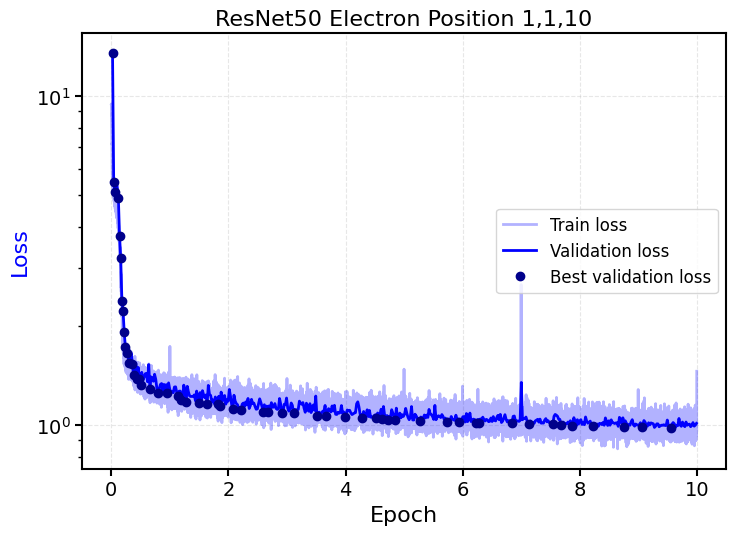

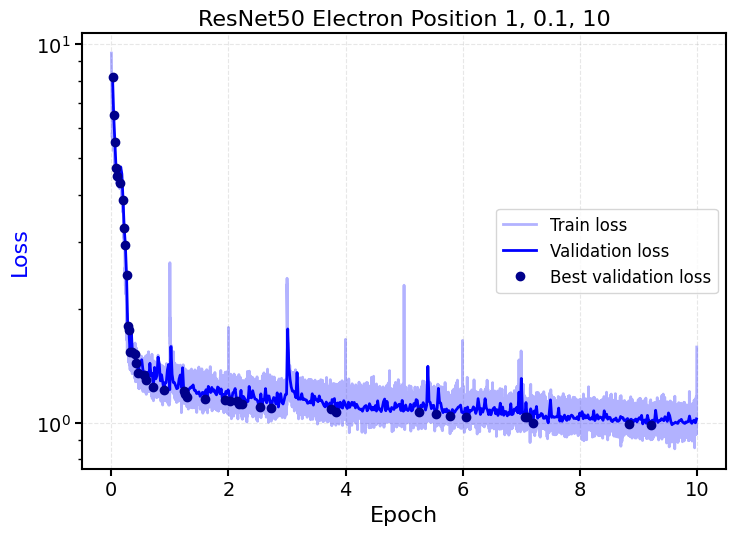

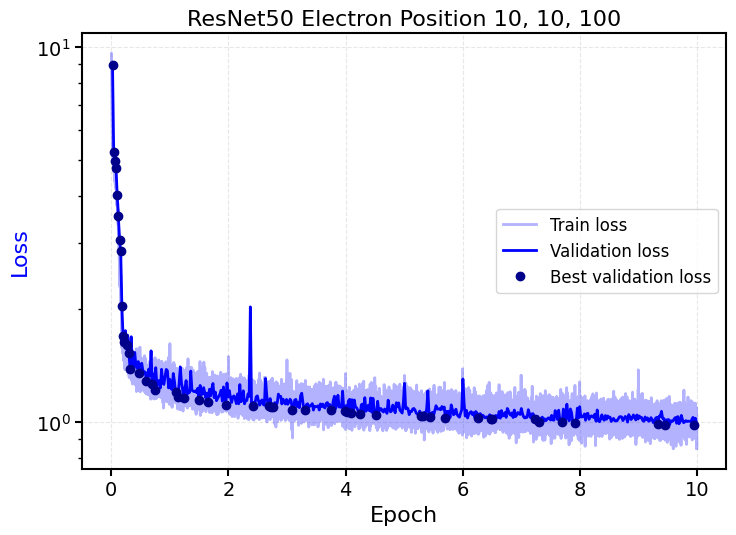

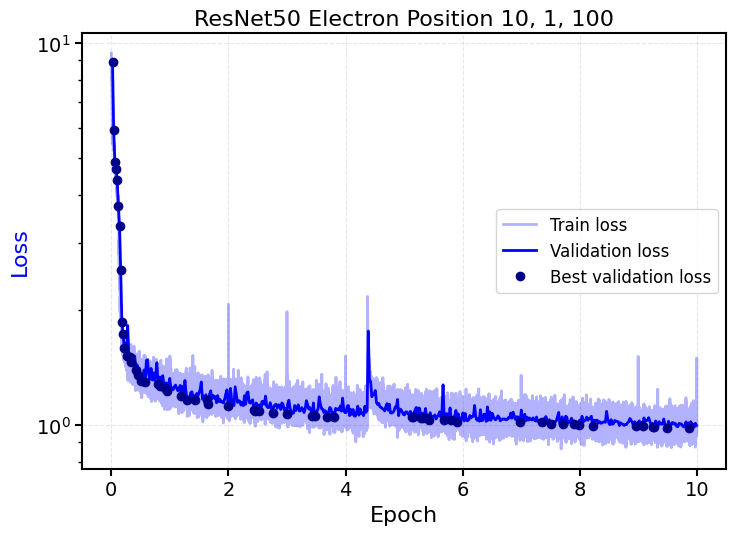

In [28]:
for r in resnet_e_pos:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')

# Statistics

In [29]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']

tabulate_statistics(resnet_muon_pos, position_stats, position_stat_labels, position_stat_types)


# 0.005 and 0.05 exact same for some reason?

,"ResNet50 Muon Position 1, 1, 10","ResNet50 Muon Position 1, 0.1, 10","ResNet50 Muon Position 10, 10, 100","ResNet50 Muon Position 10, 1, 100"
x position resolution [cm],3.64,3.94,3.72,3.74
y position resolution [cm],3.69,4.30,3.81,4.32
z position resolution [cm],3.84,3.77,3.83,3.79
3D position resolution [cm],7.06,7.62,7.16,7.47
Transverse position resolution [cm],5.90,6.59,6.11,6.41
Longitudinal position resolution [cm],3.42,3.33,3.28,3.42
Longitudinal position mean bias [cm],1.27,0.08,0.58,-0.27


In [30]:
tabulate_statistics(resnet_e_pos, position_stats, position_stat_labels, position_stat_types)

,"ResNet50 Electron Position 1,1,10","ResNet50 Electron Position 1, 0.1, 10","ResNet50 Electron Position 10, 10, 100","ResNet50 Electron Position 10, 1, 100"
x position resolution [cm],3.75,4.07,3.98,4.11
y position resolution [cm],3.66,3.96,3.77,3.87
z position resolution [cm],4.19,4.01,3.96,4.21
3D position resolution [cm],7.35,7.64,7.41,7.69
Transverse position resolution [cm],5.30,5.53,5.21,5.65
Longitudinal position resolution [cm],4.57,4.72,4.78,4.66
Longitudinal position mean bias [cm],0.49,0.50,1.67,0.49


In [31]:
#hostname
energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', 'energy_percentage_errors', 'momentum_percentage_errors','energy_percentage_errors', 'momentum_percentage_errors']
energy_stat_types = ['resolution', 'resolution', 'mean','mean', 'resolution', 'resolution','mean','mean',]

# r = resnet_muon_energy[0]
# valid = np.asarray(r.predictions) >= 105.7

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

,"ResNet 50 Muon Energy 1,1,10","ResNet 50 Muon Energy 1, 0.1, 10","ResNet 50 Muon Energy 10, 10, 100","ResNet 50 Muon Energy 10, 1, 100"
energy_residuals,6.75,6.84,6.78,6.85
momentum_residuals,7.17,7.24,7.19,7.28
energy_residuals,0.52,1.01,0.53,-0.87
momentum_residuals,0.47,1.04,0.47,-0.82
energy_percentage_errors,1.89,1.89,1.89,1.93
momentum_percentage_errors,2.15,2.15,2.15,2.19
energy_percentage_errors,0.01,0.26,-0.03,0.06
momentum_percentage_errors,-0.05,0.29,-0.09,0.14


In [32]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,"ResNet 50 Electron Energy 1,1,10","ResNet 50 Electron Energy 1, 0.1, 10","ResNet 50 Electron Energy 10, 10, 100","ResNet 50 Electron Energy 10, 1, 100"
energy_residuals,nan,21.19,nan,20.82
momentum_residuals,nan,21.19,nan,20.82
energy_residuals,nan,-22.01,nan,-22.86
momentum_residuals,nan,-22.01,nan,-22.86
energy_percentage_errors,nan,8.25,nan,8.23
momentum_percentage_errors,nan,8.25,nan,8.23
energy_percentage_errors,nan,-3.88,nan,-3.18
momentum_percentage_errors,nan,-3.88,nan,-3.18


In [33]:
# Direction statistics

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_dir, dir_stats, dir_stat_labels, dir_stat_types)

,"ResNet 50 Muon Direction 1,1,10","ResNet 50 Muon Direction 1, 0.1, 10","ResNet 50 Muon Direction 10, 10, 100","ResNet 50 Muon Direction 10, 1, 100"
Direction residual error,2.60,2.63,2.62,2.43


In [34]:
tabulate_statistics(resnet_e_dir, dir_stats, dir_stat_labels, dir_stat_types)

,"ResNet50 Electron Direction 1,1,10","ResNet50 Electron Direction 1, 0.1, 10","ResNet50 Electron Direction 10, 10, 100","ResNet50 Electron Direction 10, 1, 100"
Direction residual error,3.79,3.95,3.90,3.80


# Plots

In [35]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# print(len(A), len(B))
# print(np.array_equal(A, B))                 # identical set + order
# print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


### Muon Plots

In [36]:
# from matplotlib.ticker import MaxNLocator, LogLocator
# import matplotlib
# import matplotlib.pyplot as plt

# matplotlib.rcParams.update({
#     'axes.labelsize': 15,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# labels = np.asarray(data_new_geo_emu["labels"]).astype(int)

# mu_mask = labels == 2

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo_emu["positions"][h5_keep_idx][mu_mask],
#     true_directions=data_new_geo_emu["directions"][h5_keep_idx][mu_mask],
#     true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][mu_mask],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask],       
#     selection=cuts_new_geo_mu,
# )

muon_mom_binning = get_binning(data_new_geo_mu["momentum"], 20, 0, 1000)
muon_cos_zenith_binning = get_binning(np.cos(data_new_geo_mu["angles"][:,0]), 20, -1, 1)

muon_azimuth_binning = get_binning(data_new_geo_mu["angles"][:,1] * 180 / np.pi, 20, -180, 180)

muon_dwall_binning = get_binning(data_new_geo_mu["dwall"], 22, 50, 300)

muon_towall_binning = get_binning(data_new_geo_mu["towall"], 30, 50, 800)

In [37]:
all_runs_pos = resnet_muon_position #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Position resolution [cm]",legend=None)


NameError: name 'resnet_muon_position' is not defined

In [ ]:
all_runs_mom =  resnet_muon_energy #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position Momentum",legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Momentum resolution",legend=None)


In [ ]:
all_runs_dir =  resnet_muon_direction #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Direction resolution",legend=None)


In [ ]:
# e_mask = labels == 1

# fitqun_e = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo_emu["positions"][h5_keep_idx][e_mask],
#     true_directions=data_new_geo_emu["directions"][h5_keep_idx][e_mask],
#     true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][e_mask],
#     true_labels=1,                        
#     indices=fq_keep_idx[e_mask],       
#     selection=cuts_new_geo_e,
# )

e_mom_binning = get_binning(data_new_geo_e["momentum"], 20, 0, 1000)

e_cos_zenith_binning = get_binning(np.cos(data_new_geo_e["angles"][:,0]), 20, -1, 1)

e_azimuth_binning = get_binning(data_new_geo_e["angles"][:,1] * 180 / np.pi, 20, -180, 180)

e_dwall_binning = get_binning(data_new_geo_e["dwall"], 22, 50, 300)

e_towall_binning = get_binning(data_new_geo_e["towall"], 30, 50, 800)

all_runs_pos = resnet_e_pos #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

In [ ]:
all_runs_mom =  resnet_e_energy #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)

In [ ]:
all_runs_dir =  resnet_e_direction #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)

In [ ]:
## seems like the separate oens are worse?

# also plot more condensed and define as a func maybe